<a href="https://colab.research.google.com/github/ysn-gachon/AI-Class-202335225-nayeonsu/blob/main/Week5/breast_cancer_Regression_DL_0410fixed.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [5]:
#worst compactness 이걸 label로 회귀
import numpy as np

import pandas as pd

df = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/breast_cancer.csv')
df = df.drop(['Unnamed: 0'],axis=1)
df.head()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,label
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,0
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,0


Epoch 1/50


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


23/23 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.6948 - mse: 0.6948 - val_loss: 0.0931 - val_mse: 0.0931
Epoch 2/50
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.1588 - mse: 0.1588 - val_loss: 0.0470 - val_mse: 0.0470
Epoch 3/50
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0761 - mse: 0.0761 - val_loss: 0.0229 - val_mse: 0.0229
Epoch 4/50
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0821 - mse: 0.0821 - val_loss: 0.0373 - val_mse: 0.0373
Epoch 5/50
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0493 - mse: 0.0493 - val_loss: 0.0259 - val_mse: 0.0259
Epoch 6/50
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0530 - mse: 0.0530 - val_loss: 0.0205 - val_mse: 0.0205
Epoch 7/50
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0474 - mse: 0.0474 - val_loss: 0.0214 - val_mse: 0.0214
Epoch 8/50
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0331 - mse: 0.0331 - val_loss: 0.0176 - val_mse: 0.0176
Epoch 9/50
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0301 - mse: 0.0301 - va

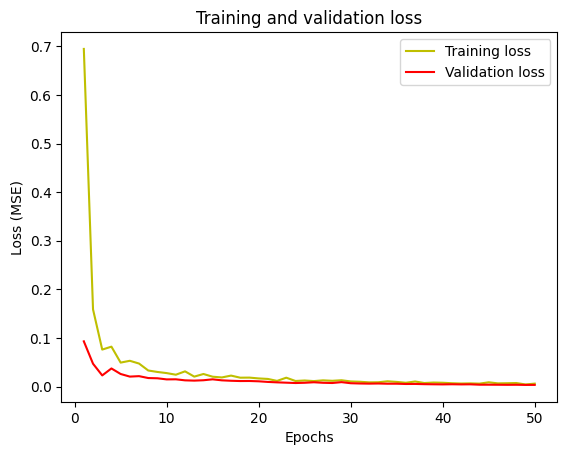

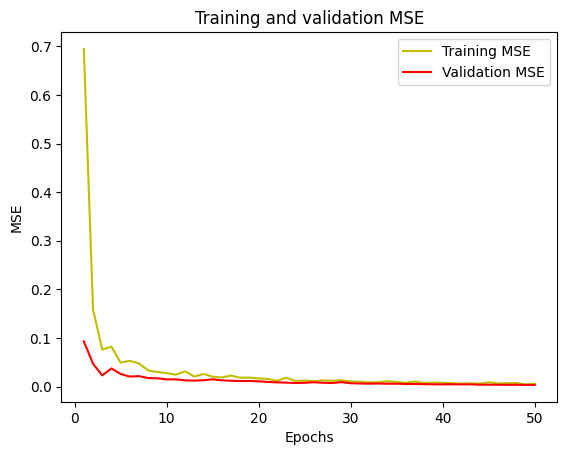

Test MSE: 0.0037
Test R-squared: 0.8754


In [6]:
#Regression

from tensorflow.keras import layers, models
from keras.models import Sequential
from keras.layers import Dense
from keras.optimizers import SGD,Adam
from sklearn.preprocessing import StandardScaler
import numpy as np
import pandas as pd
from sklearn.metrics import mean_squared_error, r2_score # Import regression metrics

# Assuming 'Alcohol' is the target variable (y) and the rest are features (X)
X = df.drop('worst compactness', axis=1)
y = df['worst compactness'].values # y is now a 1D numpy array of continuous values

scaler = StandardScaler()
X = scaler.fit_transform(X)

# Correct for regression: Do not one-hot encode y.
# For the output layer `layers.Dense(1)`, it expects a single value per sample.
# Reshape y to (n_samples, 1) for consistency with Keras input/output shape expectations.
Y = y.reshape(-1, 1)

from sklearn.model_selection import train_test_split
X_train,X_test, y_train,y_test = train_test_split(X,Y,test_size=0.2,random_state=0)


model = models.Sequential([
    layers.Dense(64, activation="relu", input_shape=(X.shape[1],)),
    layers.Dropout(0.3),
    layers.Dense(32, activation="relu"),
    layers.Dense(1)   # Output layer for regression has 1 neuron, no activation for linear output
])

model.compile(
    optimizer="adam",
    loss="mse",   # Mean Squared Error for regression
    metrics=["mse"] # Using mse as a metric for regression
)

history = model.fit(
    X_train, y_train,
    validation_split=0.2,
    epochs=50,
    batch_size=16,
    verbose=1
)

y_pred = model.predict(X_test)

# For regression, y_test_class and y_pred_class using np.argmax are inappropriate.
# We are predicting continuous values, not classes. These lines are removed.

# 학습 곡선
loss = history.history['loss']
val_loss = history.history['val_loss']
# For regression, use 'mse' instead of 'accuracy'
mse = history.history['mse']
val_mse = history.history['val_mse']


# y_pred is already calculated above.

# Again, remove classification-specific conversions for regression
# y_test_class = np.argmax(y_test,axis=1)
# y_pred_class = np.argmax(y_pred,axis=1)

import matplotlib.pyplot as plt
import seaborn as sns

loss = history.history['loss']
val_loss = history.history['val_loss']
epochs = range(1, len(loss) + 1)
plt.plot(epochs, loss, 'y', label='Training loss')
plt.plot(epochs, val_loss, 'r', label='Validation loss')
plt.title('Training and validation loss')
plt.xlabel('Epochs')
plt.ylabel('Loss (MSE)') # Update label
plt.legend()
plt.show()

# Plot MSE instead of Accuracy
plt.plot(epochs, mse, 'y', label='Training MSE')
plt.plot(epochs, val_mse, 'r', label='Validation MSE')
plt.title('Training and validation MSE') # Update title
plt.xlabel('Epochs')
plt.ylabel('MSE')
plt.legend()
plt.show()

# Accuracy metrics (classification_report, confusion_matrix) are not applicable to regression.
# Replace with appropriate regression evaluation metrics.
# Calculate MSE and R-squared on the test set
test_mse = mean_squared_error(y_test, y_pred)
test_r2 = r2_score(y_test, y_pred)

print(f"Test MSE: {test_mse:.4f}")
print(f"Test R-squared: {test_r2:.4f}")

# Removed classification metrics
# from sklearn.metrics import classification_report,confusion_matrix
# print(classification_report(y_test_class,y_pred_class))
# print(confusion_matrix(y_test_class,y_pred_class))